# Clustering — Stroke MERSCOPE (Fan / CG)

Unsupervised clustering of the Baysor-segmented cells produced by `baysor_stroke_batch.ipynb` →
`baysor_stroke_to_h5ad.ipynb`.

Input: `stroke_all.h5ad` (cells × 500-gene panel, **raw integer counts** in `X`, Baysor per-cell QC in `.obs`,
centroids in `.obsm['spatial']`, region id in `.obs['sample']`).

Pipeline:
1. QC + filtering (drop low-count / low-gene cells).
2. Normalize (total-count → log1p), keep raw counts in `layers['counts']`.
3. PCA → neighbors → Leiden → UMAP. (Optional Harmony batch correction across regions.)
4. Marker genes per cluster, UMAP + spatial plots.
5. Save `stroke_all_clustered.h5ad`.

**Kernel:** `sc`. This is a **targeted 500-gene panel**, so we cluster on *all* genes (no HVG selection).

> Re-run safe: nothing here writes back to the Baysor outputs; only a new `*_clustered.h5ad` is produced.

In [16]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from pathlib import Path

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor="white")

h5ad_dir = Path("/Volumes/T7/Stroke_merscop_Fan_CG/h5ad")
adata = sc.read_h5ad(h5ad_dir / "stroke_all.h5ad")
print(adata)
print(adata.obs["sample"].value_counts())

AnnData object with n_obs × n_vars = 2254032 × 500
    obs: 'x', 'y', 'z', 'cluster', 'n_transcripts', 'density', 'elongation', 'area', 'avg_confidence', 'avg_assignment_confidence', 'max_cluster_frac', 'lifespan', 'sample'
    obsm: 'spatial'
sample
139_mrc1_dmcao_5d_1          161673
1149_glast_dmcao_clp_7d_2    151686
141_mrc1_dmcao_14d_4         145633
619_col1a1_tmcao_14d         143446
1149_glast_dmcao_clp_7d_1    136505
141_mrc1_dmcao_14d_2         125823
1149_glast_dmcao_clp_7d_3    124845
182_mrc1_uninjured           115700
141_mrc1_dmcao_14d_1         112234
1149_glast_dmcao_clp_7d_5     89511
1151_glast_dmcao_lip_7d_1     83351
1005_glast_dmcao_5d_2         80060
139_mrc1_dmcao_5d_2           76003
122_mrc1_dcmao_2              69213
139_mrc1_dmcao_5d_3           67746
141_mrc1_dmcao_14d_3          66223
122_mrc1_dcmao_1              66000
51_mrc1_dcmao_14d             60367
1005_glast_dmcao_5d_1         60283
58_mrc1_tcmao_14d             55022
1151_glast_dmcao_lip_7d_2    

## 1. QC

Imaging-based panels are small, so cells carry few transcripts (median ~33 counts here). We look at the
distributions, then drop cells that are too sparse to type reliably and genes seen in almost no cell.

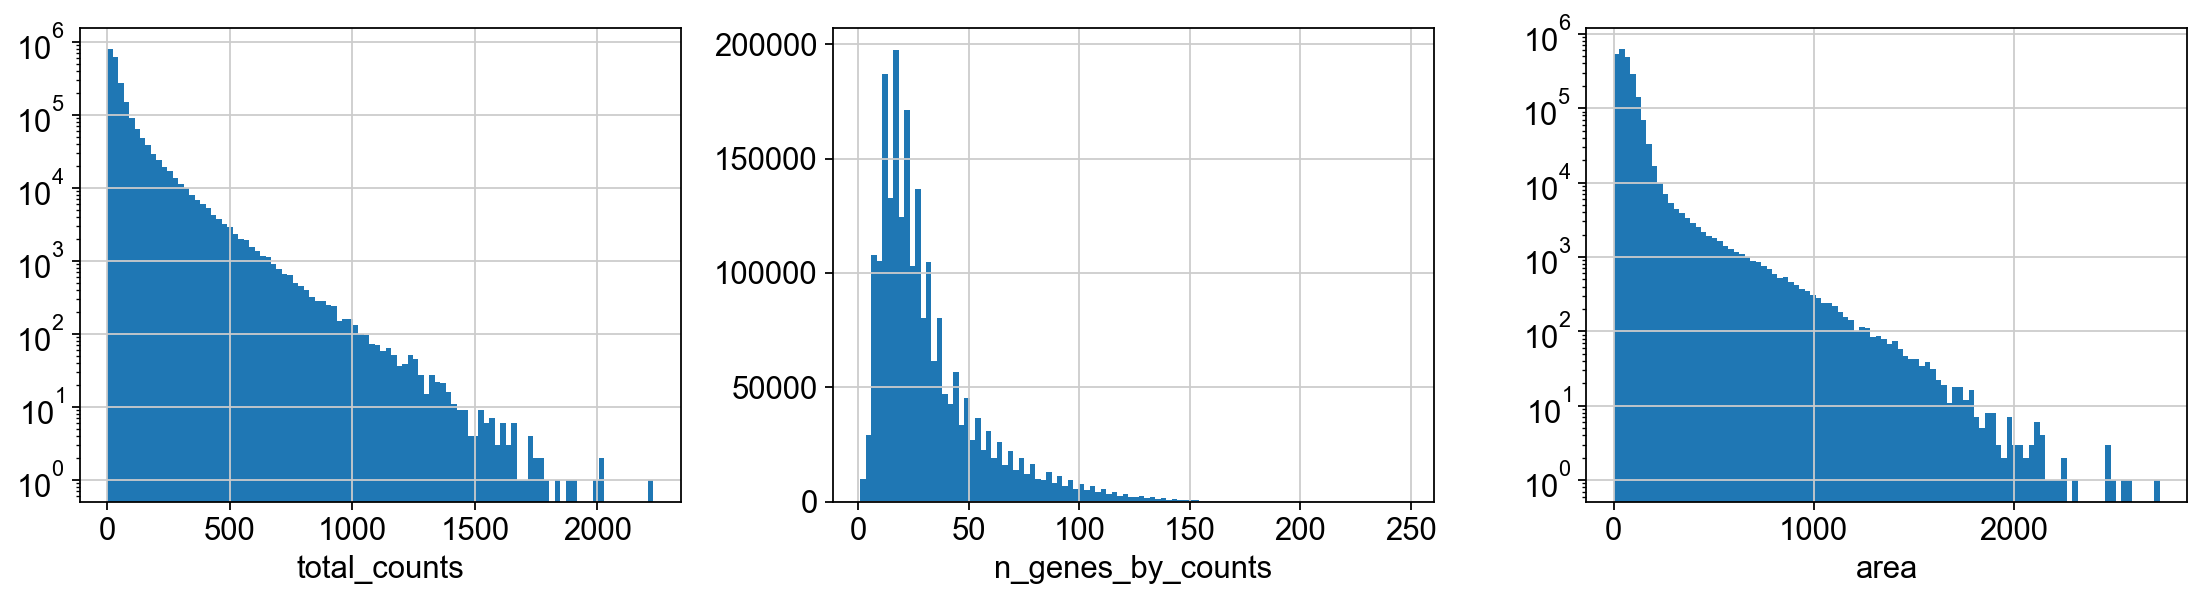

,total_counts,n_genes_by_counts
count,2.254032e+06,2.254032e+06
mean,6.579170e+01,3.239649e+01
std,9.487888e+01,2.484891e+01
min,1.000000e+00,1.000000e+00
25%,1.900000e+01,1.500000e+01
50%,3.300000e+01,2.500000e+01
75%,6.900000e+01,4.100000e+01
max,2.228000e+03,2.480000e+02


In [17]:
adata.var_names_make_unique()
sc.pp.calculate_qc_metrics(adata, percent_top=None, inplace=True)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].hist(adata.obs["total_counts"], bins=100); axs[0].set_xlabel("total_counts"); axs[0].set_yscale("log")
axs[1].hist(adata.obs["n_genes_by_counts"], bins=100); axs[1].set_xlabel("n_genes_by_counts")
if "area" in adata.obs:
    axs[2].hist(adata.obs["area"], bins=100); axs[2].set_xlabel("area"); axs[2].set_yscale("log")
plt.tight_layout(); plt.show()

adata.obs[["total_counts", "n_genes_by_counts"]].describe()

In [18]:
# --- filtering thresholds (tune to the histograms above) ---
MIN_COUNTS = 10     # min transcripts per cell
MIN_GENES  = 2     # min distinct genes per cell
MIN_CELLS  = 10     # min cells expressing a gene to keep it

n0 = adata.n_obs
sc.pp.filter_cells(adata, min_counts=MIN_COUNTS)
sc.pp.filter_cells(adata, min_genes=MIN_GENES)
sc.pp.filter_genes(adata, min_cells=MIN_CELLS)
print(f"cells: {n0} -> {adata.n_obs}  ({n0 - adata.n_obs} removed)")
print(f"genes kept: {adata.n_vars}")

cells: 2254032 -> 2112699  (141333 removed)
genes kept: 500


## 2. Normalize

Keep raw counts in `layers['counts']` (needed later for marker tests / export), then total-count normalize
and log1p.

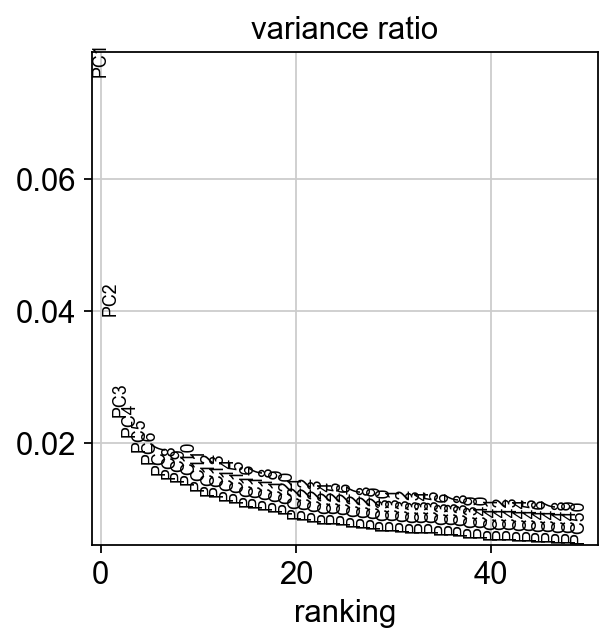

In [19]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata)        # median-count normalization
sc.pp.log1p(adata)
adata.raw = adata                    # log-normalized snapshot for plotting / DE

# Targeted panel: use all genes. Scale (clip outliers) before PCA.
#sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50)
sc.pl.pca_variance_ratio(adata, n_pcs=50)

## 3. (Optional) batch correction across regions

Three regions so far — if clusters separate by `sample` rather than biology, run Harmony on the PCA embedding.
Leave this cell unrun to cluster on the raw PCA. (`harmonypy` is pip-installed on first use.)

In [20]:
USE_HARMONY = False   # set True to batch-correct on 'sample'

rep = "X_pca"
if USE_HARMONY:
    try:
        import harmonypy  # noqa: F401
    except ModuleNotFoundError:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "harmonypy"])
    sc.external.pp.harmony_integrate(adata, key="sample")
    rep = "X_pca_harmony"
print("Using representation:", rep)

Using representation: X_pca


## 4. Neighbors → Leiden → UMAP

In [ ]:
RESOLUTION = 1.0    # higher -> more clusters

sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50, use_rep=rep)
sc.tl.leiden(adata, resolution=RESOLUTION, key_added="leiden")
sc.tl.umap(adata)
print("n clusters:", adata.obs["leiden"].nunique())
adata.obs["leiden"].value_counts().sort_index()

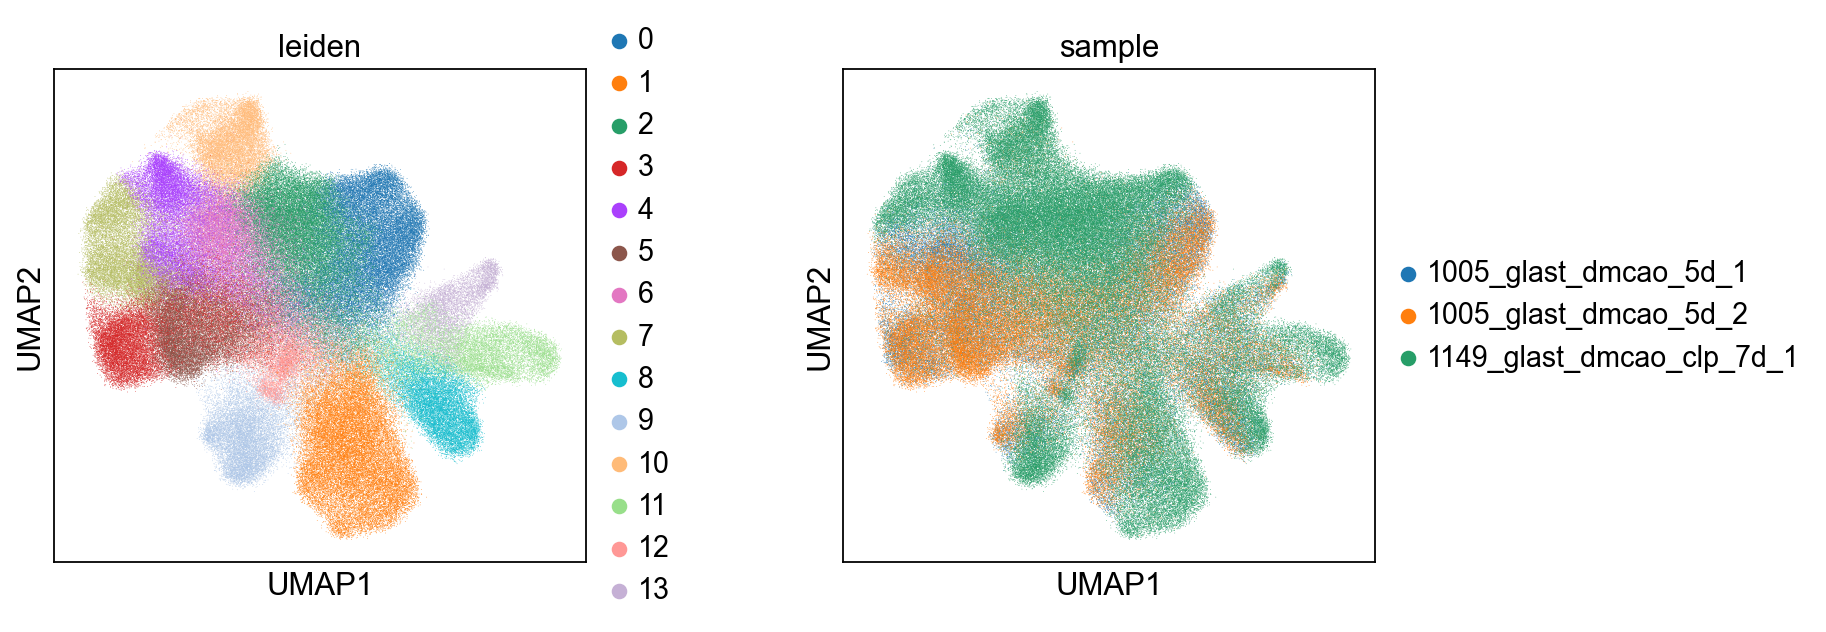

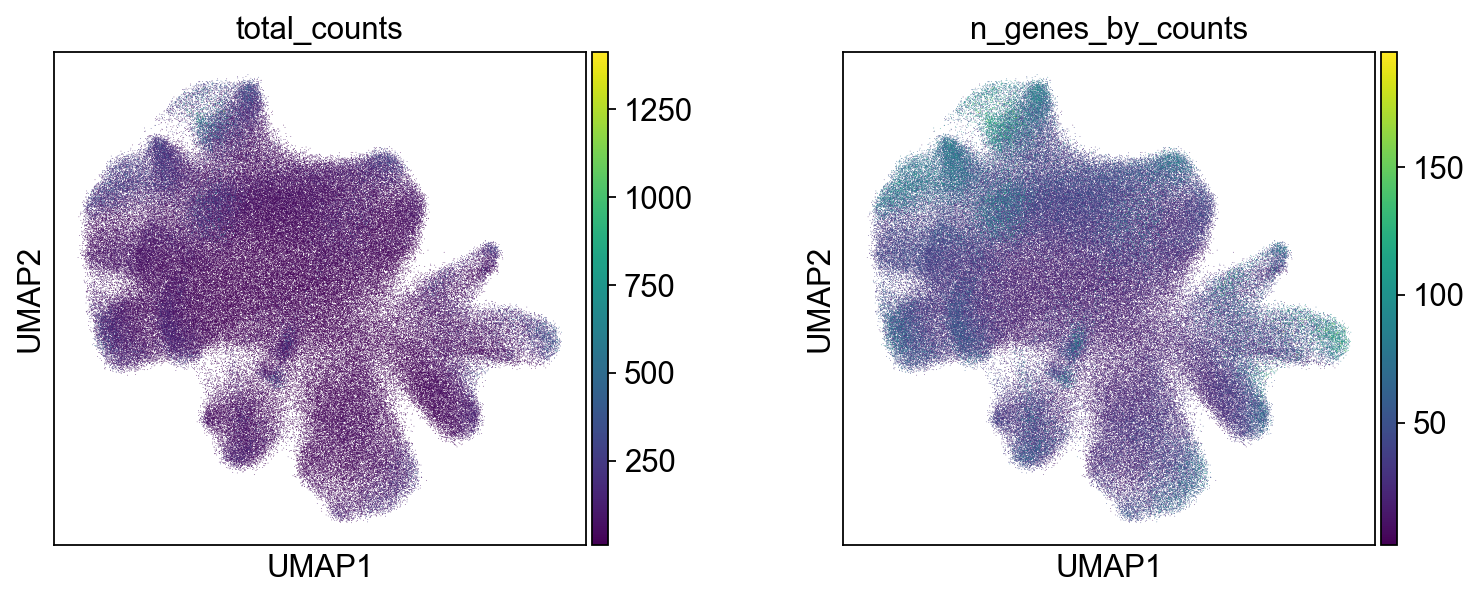

In [ ]:
sc.pl.umap(adata, color=["leiden", "sample"], wspace=0.35)
sc.pl.umap(adata, color=["total_counts", "n_genes_by_counts"], wspace=0.35)

## 5. Marker genes per cluster

Wilcoxon rank-sum on the log-normalized data (`.raw`) to find each cluster's top genes — the starting point
for annotating cell types.

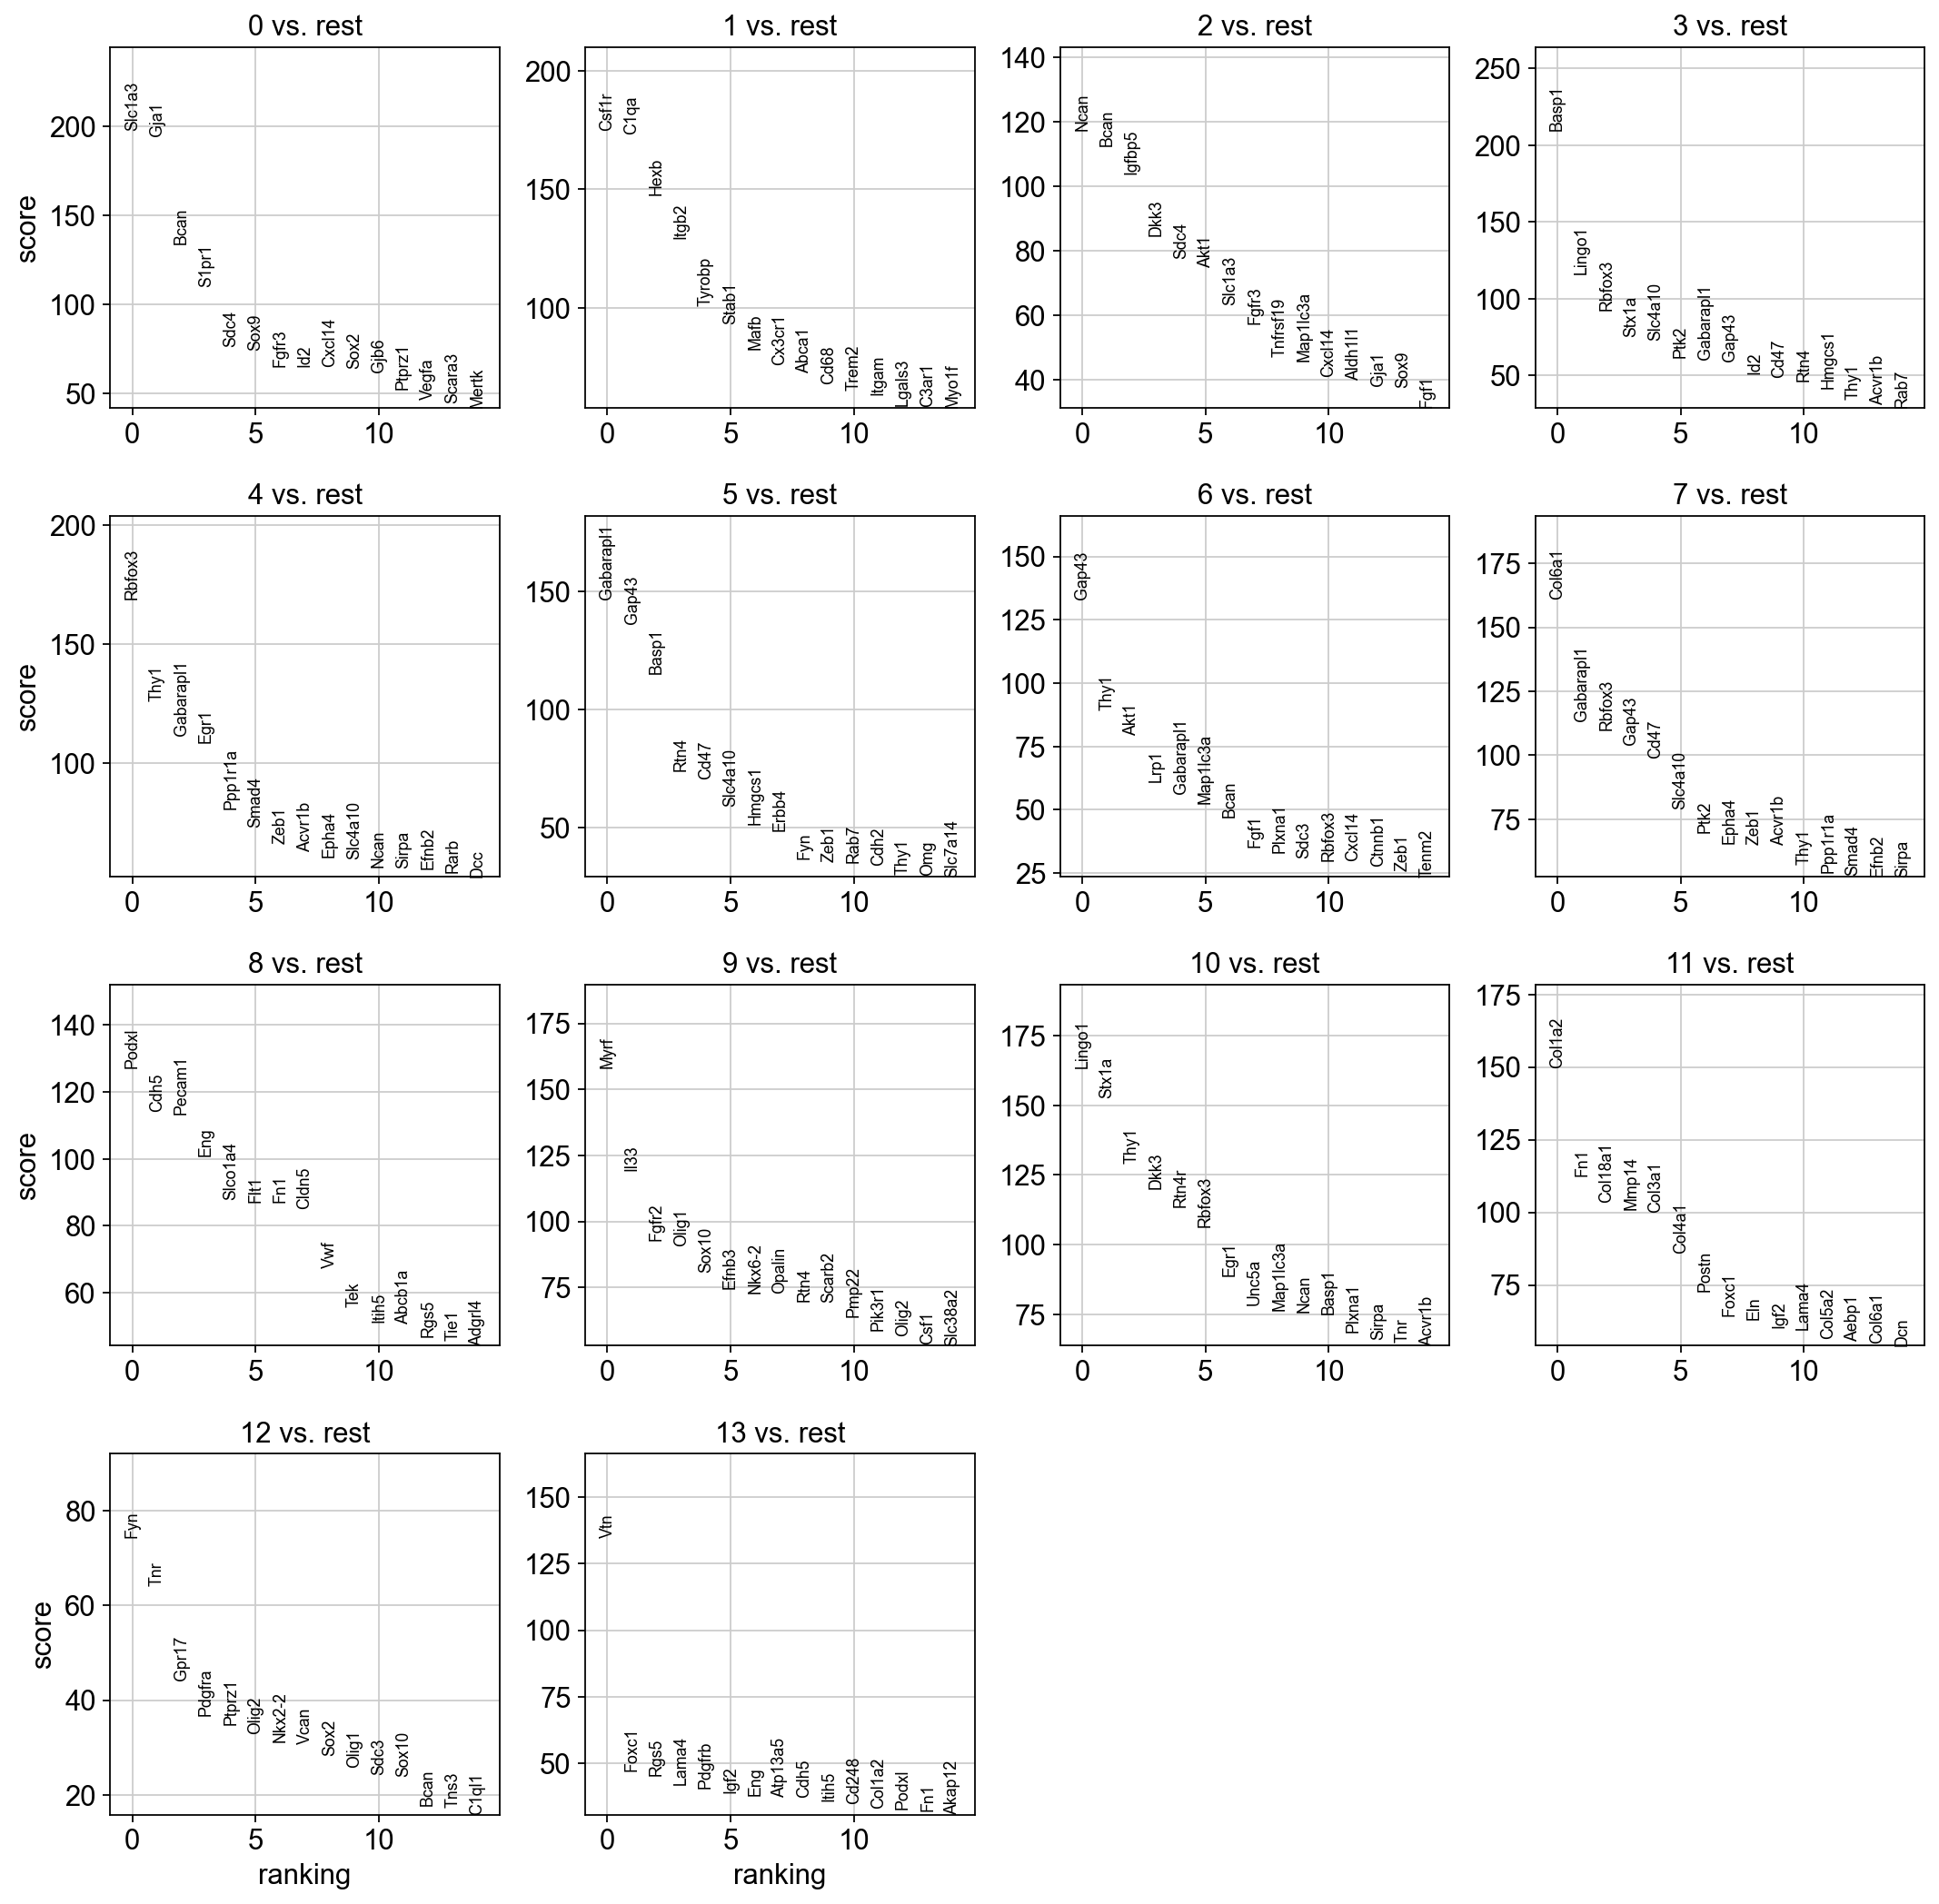

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Slc1a3,Csf1r,Ncan,Basp1,Rbfox3,Gabarapl1,Gap43,Col6a1,Podxl,Myrf,Lingo1,Col1a2,Fyn,Vtn
1,Gja1,C1qa,Bcan,Lingo1,Thy1,Gap43,Thy1,Gabarapl1,Cdh5,Il33,Stx1a,Fn1,Tnr,Foxc1
2,Bcan,Hexb,Igfbp5,Rbfox3,Gabarapl1,Basp1,Akt1,Rbfox3,Pecam1,Fgfr2,Thy1,Col18a1,Gpr17,Rgs5
3,S1pr1,Itgb2,Dkk3,Stx1a,Egr1,Rtn4,Lrp1,Gap43,Eng,Olig1,Dkk3,Mmp14,Pdgfra,Lama4
4,Sdc4,Tyrobp,Sdc4,Slc4a10,Ppp1r1a,Cd47,Gabarapl1,Cd47,Slco1a4,Sox10,Rtn4r,Col3a1,Ptprz1,Pdgfrb
5,Sox9,Stab1,Akt1,Ptk2,Smad4,Slc4a10,Map1lc3a,Slc4a10,Flt1,Efnb3,Rbfox3,Col4a1,Olig2,Igf2
6,Fgfr3,Mafb,Slc1a3,Gabarapl1,Zeb1,Hmgcs1,Bcan,Ptk2,Fn1,Nkx6-2,Egr1,Postn,Nkx2-2,Eng
7,Id2,Cx3cr1,Fgfr3,Gap43,Acvr1b,Erbb4,Fgf1,Epha4,Cldn5,Opalin,Unc5a,Foxc1,Vcan,Atp13a5
8,Cxcl14,Abca1,Tnfrsf19,Id2,Epha4,Fyn,Plxna1,Zeb1,Vwf,Rtn4,Map1lc3a,Eln,Sox2,Cdh5
9,Sox2,Cd68,Map1lc3a,Cd47,Slc4a10,Zeb1,Sdc3,Acvr1b,Tek,Scarb2,Ncan,Igf2,Olig1,Itih5


In [ ]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon", use_raw=True)
sc.pl.rank_genes_groups(adata, n_genes=15, sharey=False, fontsize=8)

top = pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(10)
top

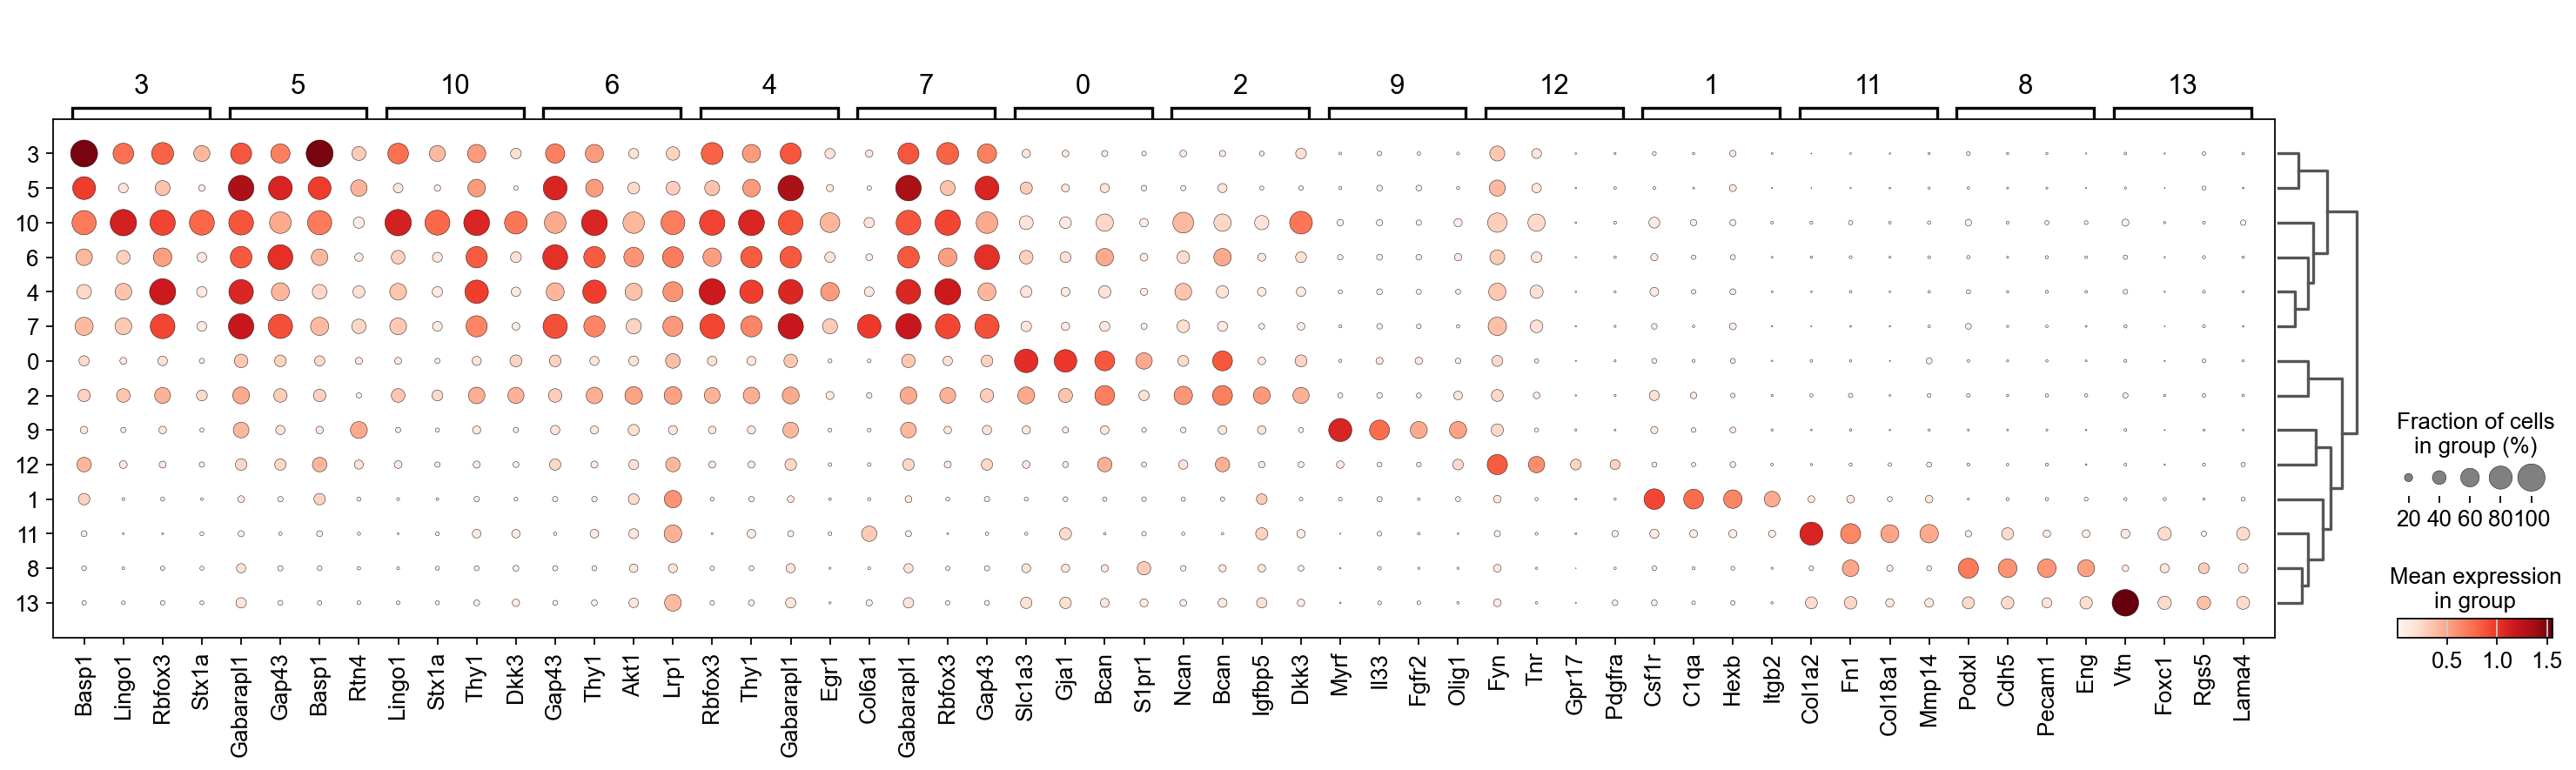

In [ ]:
# Dotplot of the top markers per cluster
sc.tl.dendrogram(adata, groupby="leiden")
sc.pl.rank_genes_groups_dotplot(adata, n_genes=4, use_raw=True)

## 6. Spatial map of clusters

Plot each region in its physical coordinates, colored by cluster, to check the clusters form coherent
anatomy (and to eyeball the lesion).

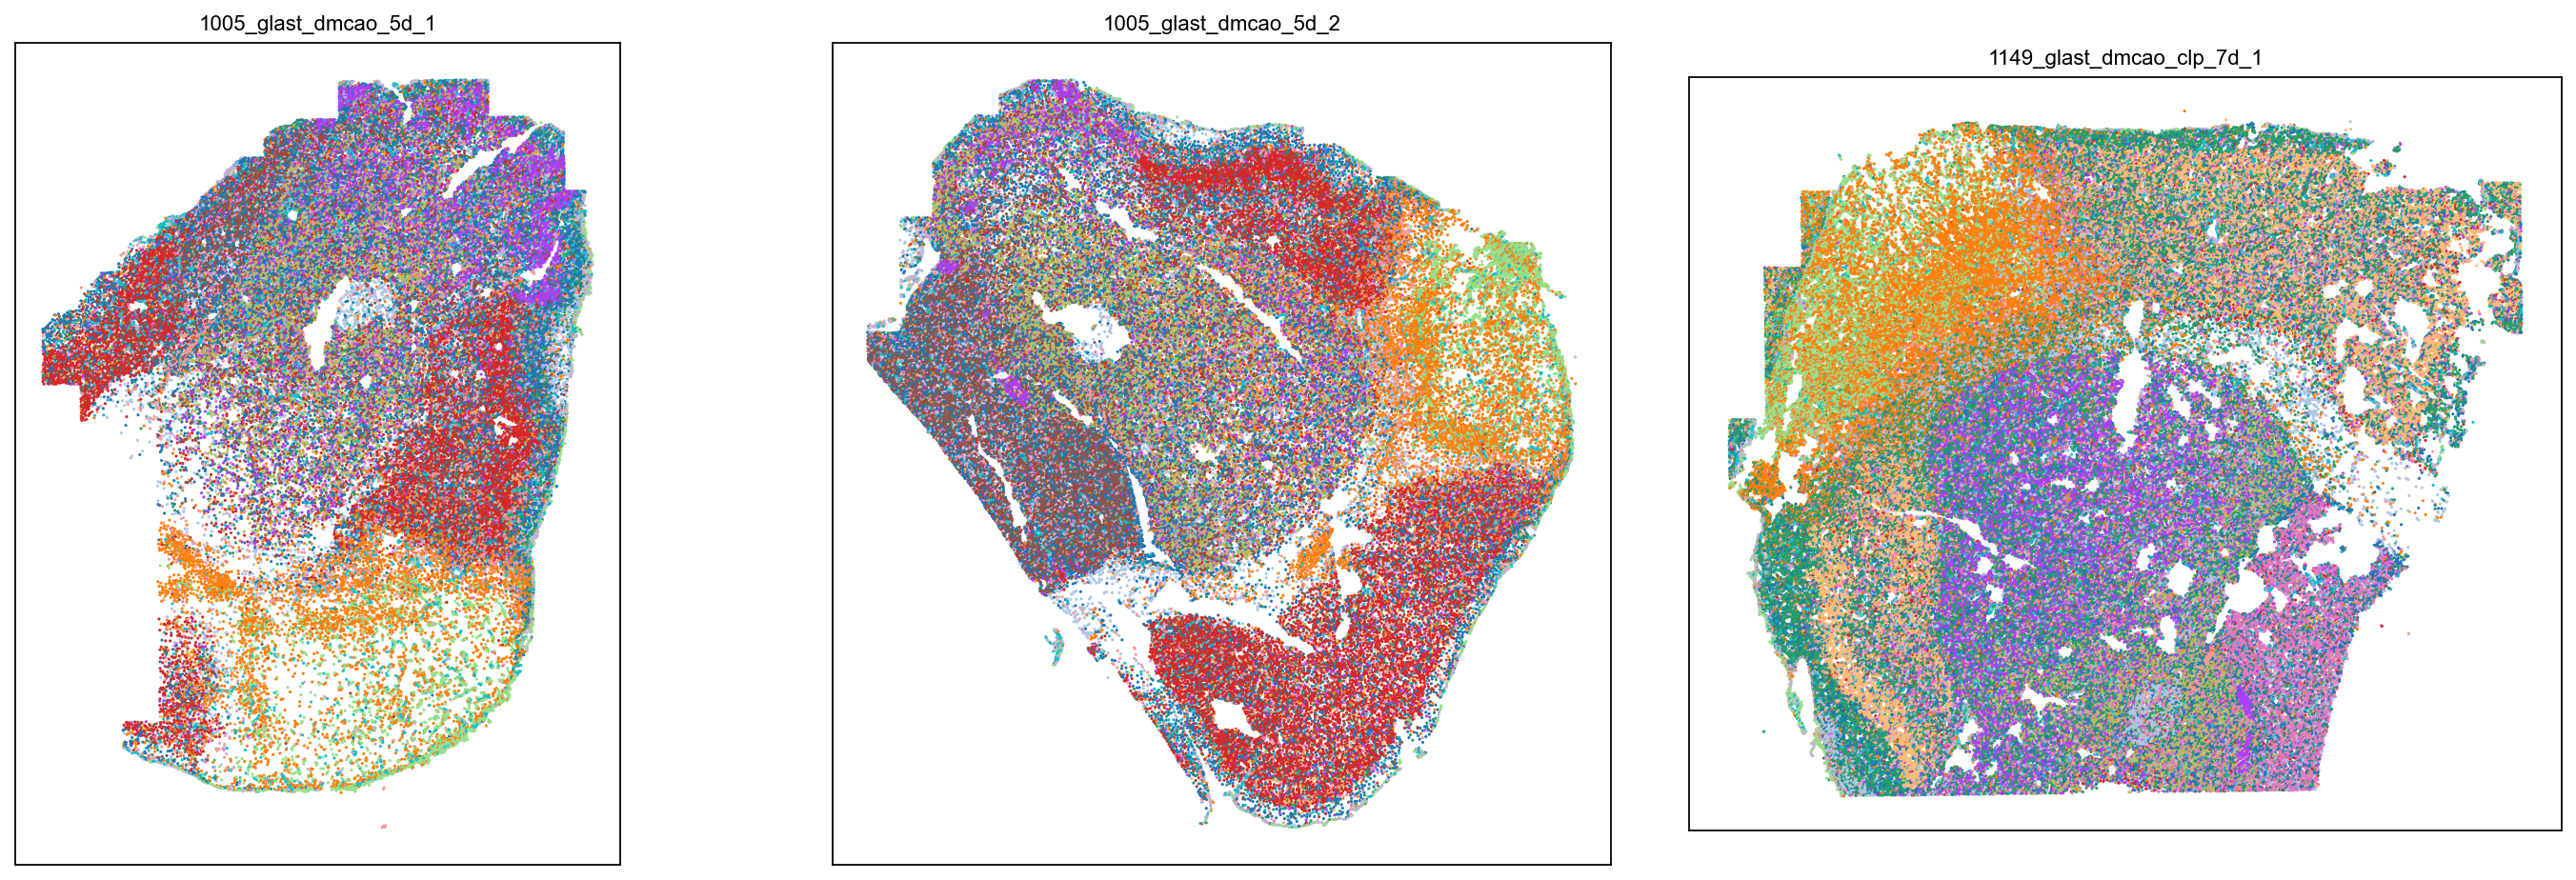

In [ ]:
samples = adata.obs["sample"].cat.categories if hasattr(adata.obs["sample"], "cat") \
    else sorted(adata.obs["sample"].unique())
n = len(samples)
ncol = min(3, n)
nrow = int(np.ceil(n / ncol))
fig, axs = plt.subplots(nrow, ncol, figsize=(6 * ncol, 6 * nrow), squeeze=False)

palette = sc.pl.palettes.default_20
clusters = list(adata.obs["leiden"].cat.categories)
color_map = {c: palette[i % len(palette)] for i, c in enumerate(clusters)}

for ax, s in zip(axs.ravel(), samples):
    sub = adata[adata.obs["sample"] == s]
    xy = sub.obsm["spatial"]
    cols = sub.obs["leiden"].map(color_map).values
    ax.scatter(xy[:, 0], xy[:, 1], c=cols, s=2, linewidths=0)
    ax.set_title(s, fontsize=10); ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
for ax in axs.ravel()[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Save

In [15]:
out_path = h5ad_dir / "stroke_all_clustered.h5ad"
adata.write_h5ad(out_path)
print("Wrote", out_path)
print(adata)

Wrote /Volumes/T7/Stroke_merscop_Fan_CG/h5ad/stroke_all_clustered.h5ad
AnnData object with n_obs × n_vars = 261026 × 500
    obs: 'x', 'y', 'z', 'cluster', 'n_transcripts', 'density', 'elongation', 'area', 'avg_confidence', 'avg_assignment_confidence', 'max_cluster_frac', 'lifespan', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'sample_colors', 'rank_genes_groups', 'dendrogram_leiden'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
